In [1]:
import numpy as np
import OpenGL.GL as gl
import cupy as cp

from cuda_kernels_lg import laguerre_cuda, hologram_cuda

In [2]:
import matplotlib.pyplot as plt

In [3]:
scale = 1.0  # Scale factor for coordinates
theta = 0  # Rotation in radians

width, height = 1920, 1080
# Generate coordinate grid
x = cp.linspace(-width / 2, width / 2, width) * scale
y = cp.linspace(-height / 2, height / 2, height) * scale
X, Y = cp.meshgrid(x, y)

In [4]:
lg_field = cp.empty_like(X, dtype=cp.complex64)

In [5]:
laguerre_cuda(X, Y, 55.0, 30, 0, 0, 0, out=lg_field)

array([[nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj],
       [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj],
       [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj],
       ...,
       [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj],
       [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj],
       [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj]],
      dtype=complex64)

In [6]:
cp.max(cp.abs(lg_field))

array(nan, dtype=float32)

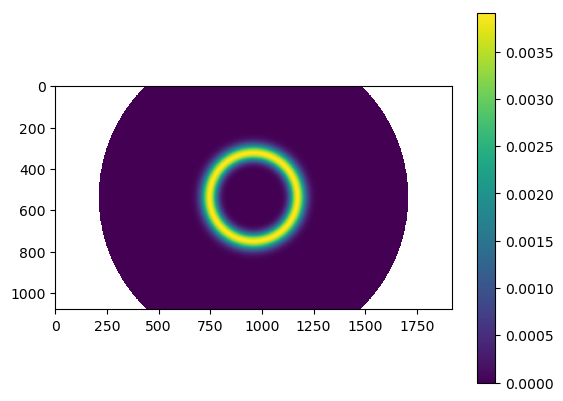

In [7]:
plt.figure()
plt.imshow(cp.abs(lg_field).get())
plt.colorbar()

In [8]:
lg_field = cp.where(cp.isnan(lg_field), 0, lg_field)

In [9]:
lg_field = lg_field/cp.max(lg_field)

In [10]:
lg_field

array([[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       ...,
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]],
      dtype=complex64)

In [11]:
holo = hologram_cuda(lg_field, X, Y, angle_deg=120, defocus=-2e-4)

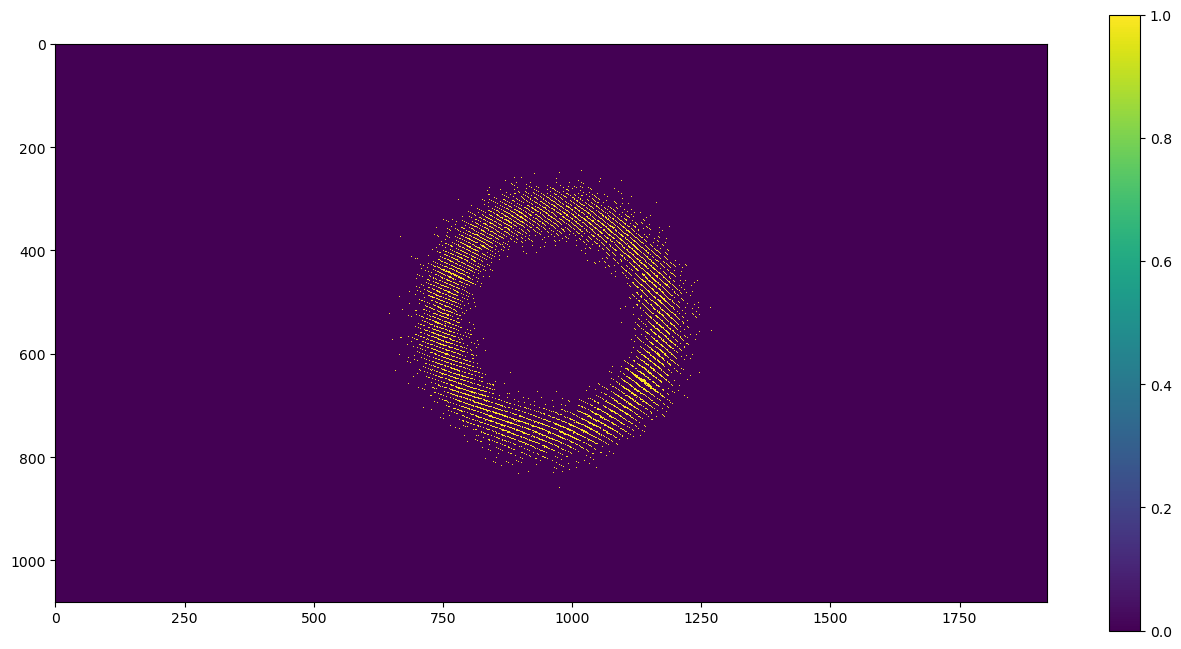

In [12]:
plt.figure(figsize=(16,8))
plt.imshow((holo).get())
plt.colorbar()

In [11]:
from cuda_kernels_lg import lg_cart_kernel

In [24]:
from cupyx.profiler import benchmark

In [40]:
benchmark(_laguerre_cuda, (X, Y, 100.0, 6, 0, 0, 0, 0, (32, 32), lg_field), n_repeat=100)

_laguerre_cuda      :    CPU:    73.688 us   +/- 13.833 (min:    67.500 / max:   170.400) us     GPU-0:   432.829 us   +/- 100.241 (min:   329.792 / max:   937.984) us

In [42]:
benchmark(_laguerre_cuda, (X, Y, 100.0, 6, 0, 0, 0, 0, (16, 1), lg_field), n_repeat=100)

_laguerre_cuda      :    CPU:    73.781 us   +/- 11.710 (min:    68.600 / max:   171.900) us     GPU-0:   716.432 us   +/- 165.674 (min:   580.864 / max:  1301.504) us

In [41]:
benchmark(_laguerre_cuda, (X, Y, 100.0, 6, 0, 0, 0, 0, (256, 1), lg_field), n_repeat=100)

_laguerre_cuda      :    CPU:    72.231 us   +/- 12.032 (min:    68.000 / max:   179.400) us     GPU-0:   391.480 us   +/- 97.879 (min:   287.776 / max:  1014.784) us

In [36]:
def _laguerre_cuda(X, Y, w, l, p, x0=0, y0=0, phase_offset=0, blockSize = 32, out=None):
    
    # threadsPerBlock = (blockSize, blockSize)
    if isinstance(blockSize, tuple):
        threadsPerBlock = blockSize
    else:
        threadsPerBlock = (blockSize, blockSize)

    N, M = X.shape

    numBlocks = ((M + threadsPerBlock[0] - 1) // threadsPerBlock[0], (N + threadsPerBlock[1] - 1) // threadsPerBlock[1])
    if out is None:
        out = cp.empty_like(X, dtype=cp.complex64)
    else:
        assert out.dtype == cp.complex64
    #print(numBlocks)
    lg_cart_kernel(numBlocks, threadsPerBlock, (X.astype(cp.float32), Y.astype(cp.float32), out, 
                                                cp.float32(w), cp.int32(l), cp.int32(p), cp.float32(x0), cp.float32(y0), cp.float32(phase_offset), 
                                                cp.int32(N), cp.int32(M)))  # grid, block and arguments
    
    return out